/var/folders/z9/0b_f0vqx7yz487m29qrdk82w0000gn/T/ipykernel_6689/1758705572.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['variance'][i] = std_freq[i]**2
/var/folders/z9/0b_f0vqx7yz487m29qrdk82w0000gn/T/ipykernel_6689/1758705572.py:124: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", len(legend_df))


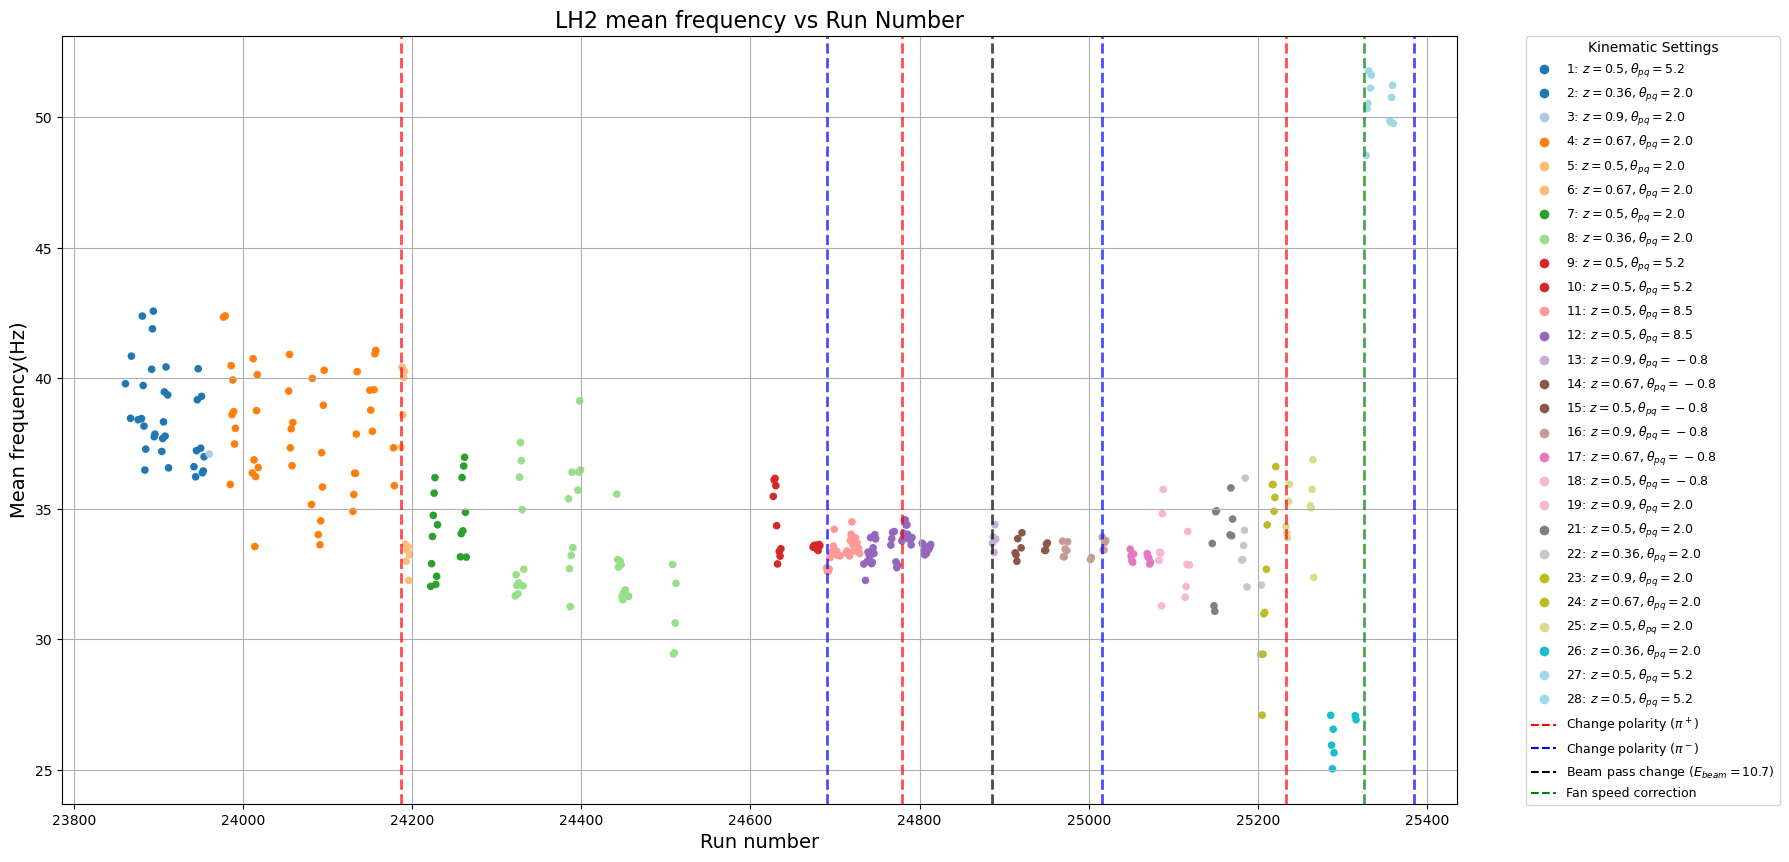

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv('hcL2_Fan_Freq_R.csv')
runs = df['run'].to_numpy()
mean_freq = df['mean'].to_numpy()
std_freq = df['stdev'].to_numpy()
norm_yield = df['normyield'].to_numpy()

df["variance"] = np.nan

for i in range(len(std_freq)):
    df['variance'][i] = std_freq[i]**2


settings = [
    (df['run']>=23861) & (df['run']<=23868),
    (df['run']>=23876) & (df['run']<=23954),
    (df['run']>=23957) & (df['run']<=23962),
    (df['run']>=23977) & (df['run']<=24082),
    (df['run']>=24089) & (df['run']<=24179),
    (df['run']>=24187) & (df['run']<=24197),
    (df['run']>=24222) & (df['run']<=24264),
    (df['run']>=24322) & (df['run']<=24399),
    (df['run']>=24442) & (df['run']<=24512),
    (df['run']>=24627) & (df['run']<=24683),
    (df['run']>=24690) & (df['run']<=24729),
    (df['run']>=24734) & (df['run']<=24774),
    (df['run']>=24779) & (df['run']<=24813),
    (df['run']>=24886) & (df['run']<=24890),
    (df['run']>=24913) & (df['run']<=24951),
    (df['run']>=24969) & (df['run']<=25003),
    (df['run']>=25016) & (df['run']<=25020),
    (df['run']>=25049) & (df['run']<=25073),
    (df['run']>=25083) & (df['run']<=25119),
    (df['run']>=25122) & (df['run']<=25124),
    (df['run']>=25146) & (df['run']<=25170),
    (df['run']>=25181) & (df['run']<=25452),
    (df['run']>=25205) & (df['run']<=25221),
    (df['run']>=25233) & (df['run']<=25237),
    (df['run']>=25262) & (df['run']<=25266),
    (df['run']>=25286) & (df['run']<=25316),
    (df['run']>=25328) & (df['run']<=25334),
    (df['run']>=25356) & (df['run']<=25382),
    (df['run']>=25434) & (df['run']<=25442),
    (df['run']>=25384) & (df['run']<=25389),
    (df['run']>=25423) & (df['run']<=25430),
 ]


setting_names = [
    r"$z=0.5, \theta_{pq}=5.2$",
    r"$z=0.36, \theta_{pq}=2.0$",
    r"$z=0.9, \theta_{pq}=2.0$",
    r"$z=0.67, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=2.0$",
    r"$z=0.67, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=2.0$",
    r"$z=0.36, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=5.2$",
    r"$z=0.5, \theta_{pq}=5.2$",
    r"$z=0.5, \theta_{pq}=8.5$",
    r"$z=0.5, \theta_{pq}=8.5$",
    r"$z=0.9, \theta_{pq}=-0.8$",
    r"$z=0.67, \theta_{pq}=-0.8$",
    r"$z=0.5, \theta_{pq}=-0.8$",
    r"$z=0.9, \theta_{pq}=-0.8$",
    r"$z=0.67, \theta_{pq}=-0.8$",
    r"$z=0.5, \theta_{pq}=-0.8$",
    r"$z=0.9, \theta_{pq}=2.0$",
    r"$z=0.67, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=2.0$",
    r"$z=0.36, \theta_{pq}=2.0$",
    r"$z=0.9, \theta_{pq}=2.0$",
    r"$z=0.67, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=2.0$",
    r"$z=0.36, \theta_{pq}=2.0$",
    r"$z=0.5, \theta_{pq}=5.2$",
    r"$z=0.5, \theta_{pq}=5.2$",
    r"$z=0.5, \theta_{pq}=8.5$",
    r"$z=0.9, \theta_{pq}=2.0$"
]

# Assign a setting number to each run
df["setting_label"] = np.nan  # initialize empty column
df["setting_id"] = np.nan  # initialize empty column

for i, (condition, name) in enumerate(zip(settings, setting_names), start=1):
    mask = condition & df["setting_id"].isna()
    df.loc[condition, "setting_label"] = name
    df.loc[condition, "setting_id"] = i



plt.figure(figsize=(18, 9))

scatter = plt.scatter(runs, mean_freq, c=df["setting_id"].astype(float), cmap="tab20", s=20)

# Add colorbar with labels
# cbar = plt.colorbar(scatter)
# cbar.set_label("Kinematic Setting")

vertical_lines = [24187, 24690, 24779, 24886, 25016 ,25233, 25325, 25384]
line_labels = [r"Change polarity $(\pi^+)$", r"Change polarity $(\pi^-)$", r"Beam pass change $(E_{beam}=10.7)$", r"Fan speed correction"]
line_colors = ["r", "b", "k", "g"]
line_cols = ["r", "b", "r", "k", "b", "r", "g","b"]

plt.xlabel("Run number", fontsize=14)
plt.ylabel("Mean frequency(Hz)", fontsize=14)   
plt.title("LH2 mean frequency vs Run Number", fontsize=16)

# --- Legend ---
legend_df = (
    df.dropna(subset=["setting_id"]) 
      .drop_duplicates("setting_id")[["setting_id","setting_label"]]
      .sort_values("setting_id")
)


cmap = plt.cm.get_cmap("tab20", len(legend_df))
colors = [cmap(j) for j in range(len(legend_df))]

handles = [
    plt.Line2D([0], [0], marker="o", color="w", 
               markerfacecolor=colors[j], markersize=8, 
               label=f"{int(row.setting_id)}: {row.setting_label}")
    for j, row in enumerate(legend_df.itertuples(index=False))
]

line_handles = [plt.Line2D([0],[0], color=col, linestyle="--", label=lbl)
                for lbl, col in zip(line_labels, line_colors)]

for x, col in zip(vertical_lines,line_cols):
    plt.axvline(x=x, color=col, linestyle="--", linewidth=2, alpha=0.7)

plt.legend(handles=handles+line_handles, title="Kinematic Settings",
           bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0., fontsize=9)

plt.grid()
plt.tight_layout()
plt.show()

# plt.hexbin(runs, mean_freq, gridsize=50, cmap='viridis')
# plt.errorbar(runs, norm_mean, yerr=std_freq, fmt='o', color='k', label='Mean Fan Frequency')
# plt.errorbar(runs, mean_freq, yerr=std_freq, fmt='o', color='k', label='Mean Fan Frequency')
# plt.scatter(runs, mean_freq, color='k', label='Mean Fan Frequency')
# plt.xscale('log')
# plt.yscale('logit')




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


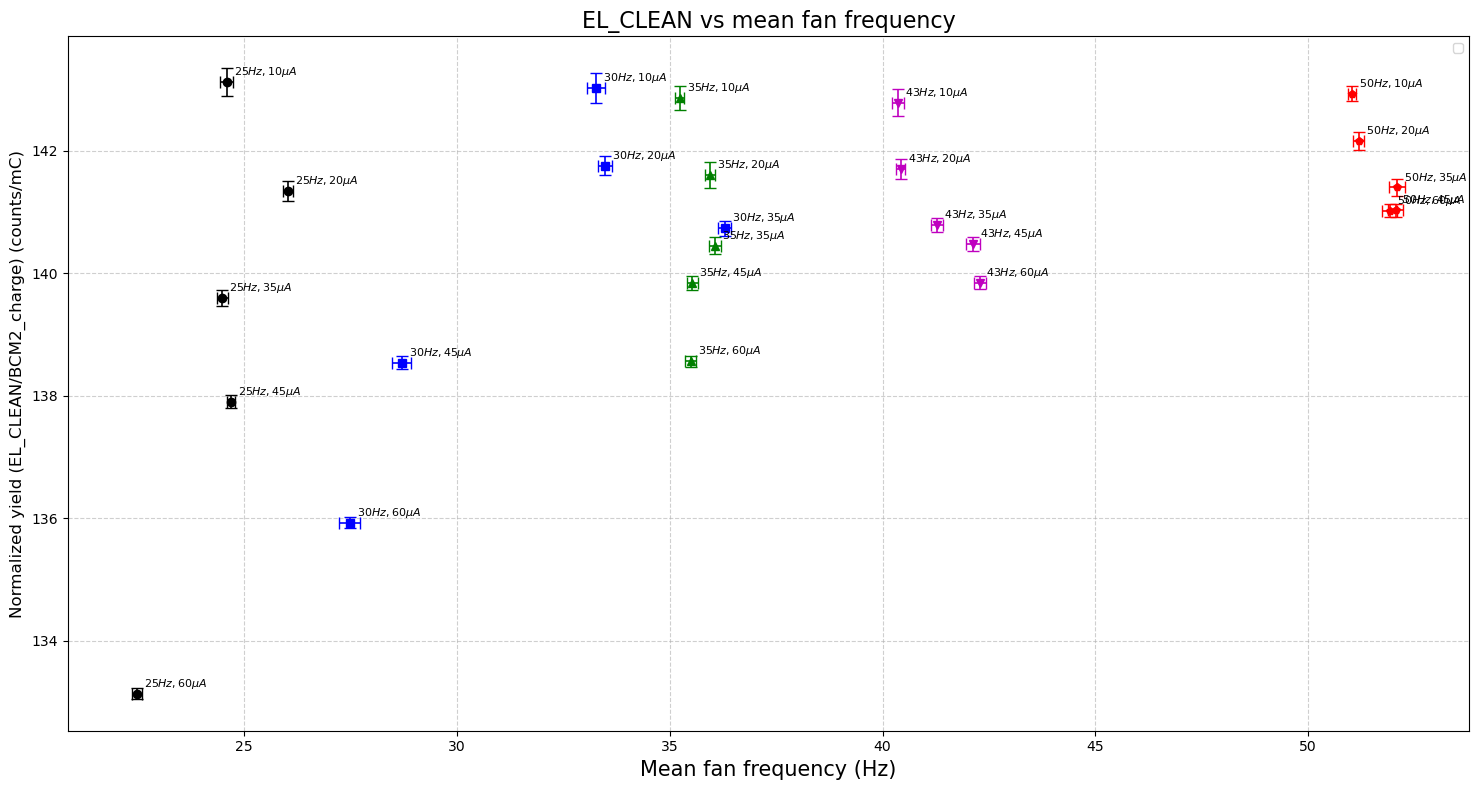

In [3]:
new_df = pd.read_csv("fan_studies_runs.csv")
el_clean = new_df['EL_CLEAN'].to_numpy()
charge = new_df['BCM2_charge'].to_numpy()
current = new_df['BCM2_current'].to_numpy()
nom_current = new_df['current'].to_numpy()
ps3 = new_df['ps3'].to_numpy()
ps4 = new_df['ps4'].to_numpy()
std_freq = new_df['stdev'].to_numpy()
speed = new_df['speed'].to_numpy()
counts = new_df['updateCount'].to_numpy()
mean_freq = new_df['mean'].to_numpy()

norm_yield = (el_clean/charge)

yerror = (np.sqrt(el_clean)/charge)
xerror = std_freq/np.sqrt(counts)

annotations = [r"$50Hz, 10µA$", r"$50Hz, 20µA$", r"$50Hz,35µA$", r"$50Hz,45µA$", r"$50Hz,60µA$", r"$43Hz,60µA$", r"$43Hz,45µA$", r"$43Hz,35µA$", r"$43Hz,20µA$", r"$43Hz,10µA$", r"$35Hz,10µA$", r"$35Hz,20µA$", r"$35Hz,35µA$", r"$35Hz,45µA$", r"$35Hz,60µA$", r"$30Hz,60µA$", r"$30Hz,45µA$", r"$30Hz,35µA$", r"$30Hz,20µA$", r"$30Hz,10µA$", r"$25Hz,10µA$", r"$25Hz,20µA$", r"$25Hz,35µA$", r"$25Hz,45µA$", r"$25Hz,60µA$"]
plt.figure(figsize=(15, 8))

plt.errorbar(mean_freq[new_df["speed"]==25], norm_yield[new_df["speed"]==25], xerr=xerror[new_df["speed"]==25], yerr=yerror[new_df["speed"]==25], fmt='ko', elinewidth=1.2, capsize=4)
plt.errorbar(mean_freq[new_df["speed"]==30], norm_yield[new_df["speed"]==30], xerr=xerror[new_df["speed"]==30], yerr=yerror[new_df["speed"]==30], fmt='bs', elinewidth=1.2, capsize=4)
plt.errorbar(mean_freq[new_df["speed"]==35], norm_yield[new_df["speed"]==35], xerr=xerror[new_df["speed"]==35], yerr=yerror[new_df["speed"]==35], fmt='g^', elinewidth=1.2, capsize=4)
plt.errorbar(mean_freq[new_df["speed"]==43], norm_yield[new_df["speed"]==43], xerr=xerror[new_df["speed"]==43], yerr=yerror[new_df["speed"]==43], fmt='mv', elinewidth=1.2, capsize=4)
plt.errorbar(mean_freq[new_df["speed"]==50], norm_yield[new_df["speed"]==50], xerr=xerror[new_df["speed"]==50], yerr=yerror[new_df["speed"]==50], fmt='rp', elinewidth=1.2, capsize=4)
# plt.text(33, 20025, r"$z=0.9 , \theta_{pq}=2.0 , I_{beam}=50 \mu A $ ",
#         fontsize=13, color="black",
#         fontweight="bold", ha="center", va="center",
#         bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7))


for xi, yi, label in zip(mean_freq, norm_yield, annotations):
    plt.annotate(f"{label}",
                (xi, yi),
                textcoords="offset points",
                xytext=(5, 5),
                ha='left', fontsize=8)


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=9)
plt.title("EL_CLEAN vs mean fan frequency", fontsize=16)
plt.xlabel('Mean fan frequency (Hz)', fontsize=15)
plt.ylabel('Normalized yield (EL_CLEAN/BCM2_charge) (counts/mC)', fontsize=12)
plt.tight_layout()
plt.show()

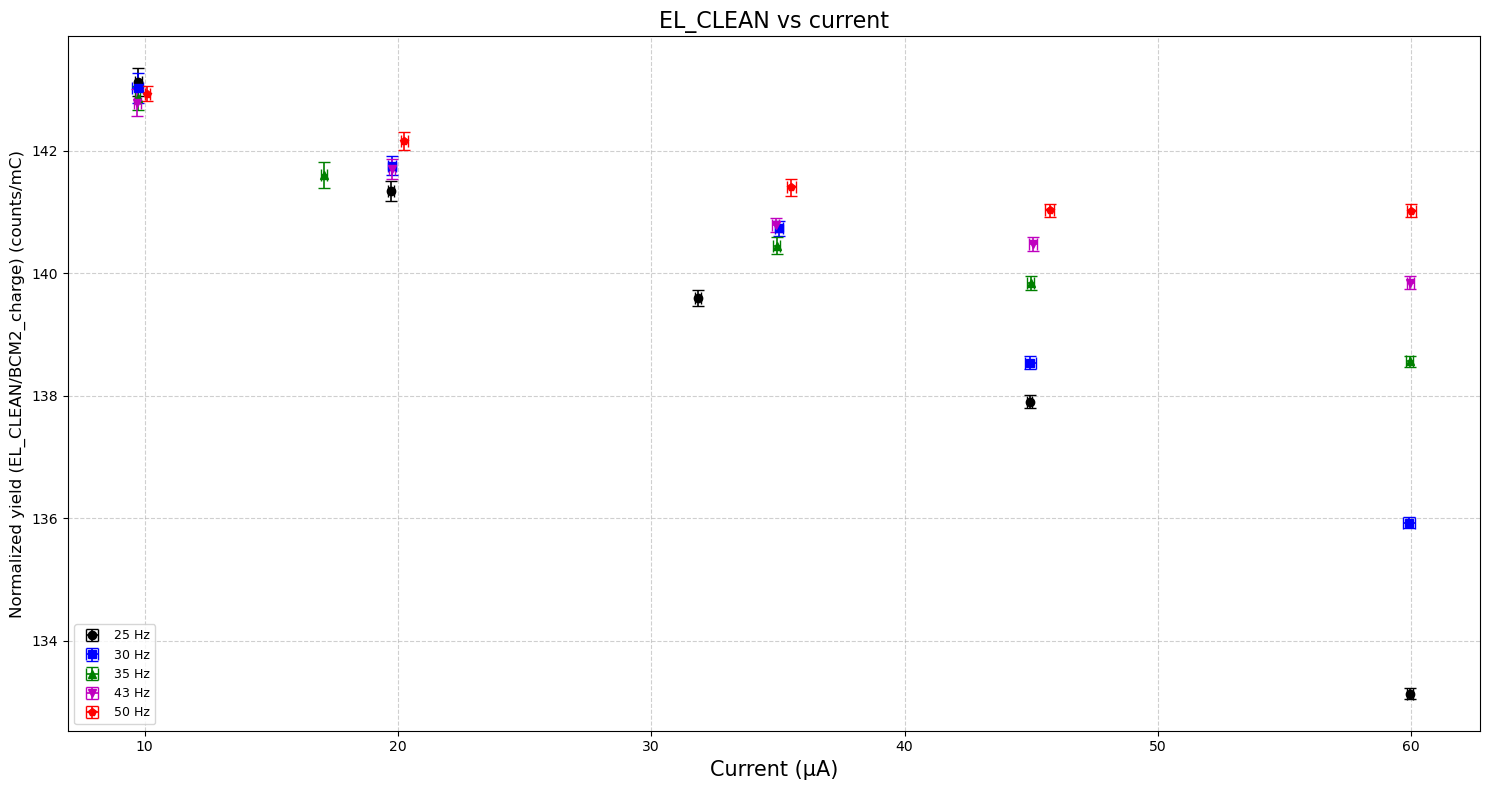

In [4]:
plt.figure(figsize=(15, 8))

plt.errorbar(current[new_df["speed"]==25], norm_yield[new_df["speed"]==25], xerr=xerror[new_df["speed"]==25], yerr=yerror[new_df["speed"]==25], fmt='ko', elinewidth=1.2, capsize=4,label='25 Hz')
plt.errorbar(current[new_df["speed"]==30], norm_yield[new_df["speed"]==30], xerr=xerror[new_df["speed"]==30], yerr=yerror[new_df["speed"]==30], fmt='bs', elinewidth=1.2, capsize=4, label='30 Hz')
plt.errorbar(current[new_df["speed"]==35], norm_yield[new_df["speed"]==35], xerr=xerror[new_df["speed"]==35], yerr=yerror[new_df["speed"]==35], fmt='g^', elinewidth=1.2, capsize=4, label='35 Hz')
plt.errorbar(current[new_df["speed"]==43], norm_yield[new_df["speed"]==43], xerr=xerror[new_df["speed"]==43], yerr=yerror[new_df["speed"]==43], fmt='mv', elinewidth=1.2, capsize=4, label='43 Hz')
plt.errorbar(current[new_df["speed"]==50], norm_yield[new_df["speed"]==50], xerr=xerror[new_df["speed"]==50], yerr=yerror[new_df["speed"]==50], fmt='rp', elinewidth=1.2, capsize=4, label='50 Hz')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=9, loc='lower left')
plt.title("EL_CLEAN vs current", fontsize=16)
plt.xlabel('Current (µA)', fontsize=15)
plt.ylabel('Normalized yield (EL_CLEAN/BCM2_charge) (counts/mC)', fontsize=12)
plt.tight_layout()
plt.show()

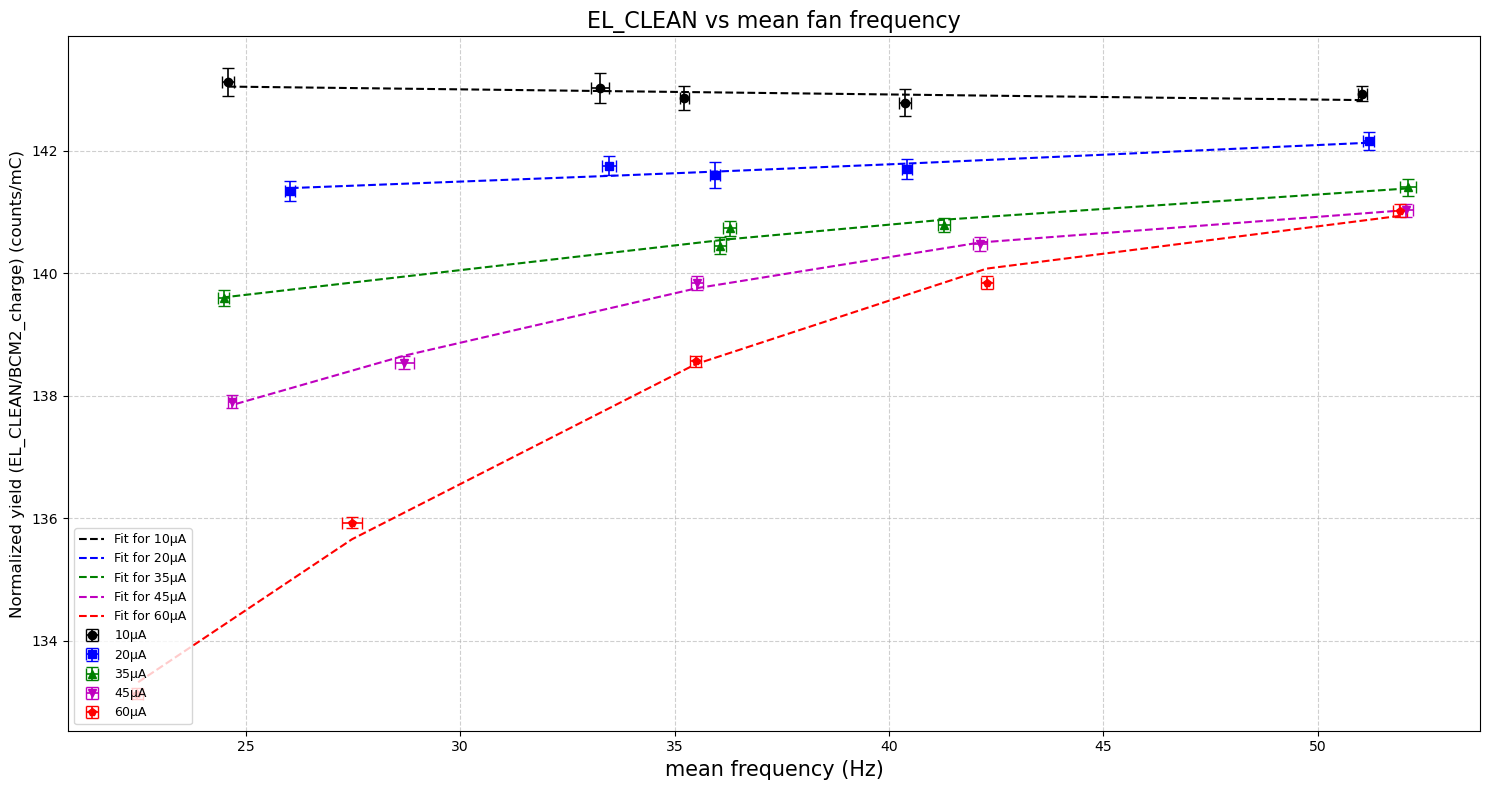

In [5]:
# a10, b10, c10 = np.polyfit(mean_freq[new_df["current"]==10], norm_yield[new_df["current"]==10], 2, cov=True)[0]
# cov10 = np.polyfit(mean_freq[new_df["current"]==10], norm_yield[new_df["current"]==10], 2, cov=True)[1]
b10, c10 = np.polyfit(mean_freq[new_df["current"]==10], norm_yield[new_df["current"]==10], 1, cov=True)[0]
cov10 = np.polyfit(mean_freq[new_df["current"]==10], norm_yield[new_df["current"]==10], 1, cov=True)[1]
a20, b20, c20 = np.polyfit(mean_freq[new_df["current"]==20], norm_yield[new_df["current"]==20], 2, cov=True)[0]
cov20 = np.polyfit(mean_freq[new_df["current"]==20], norm_yield[new_df["current"]==20], 2, cov=True)[1]
a35, b35, c35 = np.polyfit(mean_freq[new_df["current"]==35], norm_yield[new_df["current"]==35], 2, cov=True)[0]
cov35 = np.polyfit(mean_freq[new_df["current"]==35], norm_yield[new_df["current"]==35], 2, cov=True)[1]
a45, b45, c45 = np.polyfit(mean_freq[new_df["current"]==45], norm_yield[new_df["current"]==45], 2, cov=True)[0]
cov45 = np.polyfit(mean_freq[new_df["current"]==45], norm_yield[new_df["current"]==45], 2, cov=True)[1]
a60, b60, c60 = np.polyfit(mean_freq[new_df["current"]==60], norm_yield[new_df["current"]==60], 2, cov=True)[0]
cov60 = np.polyfit(mean_freq[new_df["current"]==60], norm_yield[new_df["current"]==60], 2, cov=True)[1]

# err_a10, err_b10, err_c10 = np.sqrt(np.diag(cov10))
err_b10, err_c10 = np.sqrt(np.diag(cov10))
err_a20, err_b20, err_c20 = np.sqrt(np.diag(cov20))
err_a35, err_b35, err_c35 = np.sqrt(np.diag(cov35))
err_a45, err_b45, err_c45 = np.sqrt(np.diag(cov45)) 
err_a60, err_b60, err_c60 = np.sqrt(np.diag(cov60))

plt.figure(figsize=(15, 8))

# plt.plot(mean_freq[new_df["current"]==10], a10 * (mean_freq[new_df["current"]==10])**2 + b10 * (mean_freq[new_df["current"]==10]) + c10, color='k', linestyle='--', label='Fit for 10µA')
plt.plot(mean_freq[new_df["current"]==10], b10 * (mean_freq[new_df["current"]==10]) + c10, color='k', linestyle='--', label='Fit for 10µA')
plt.plot(mean_freq[new_df["current"]==20], a20 * (mean_freq[new_df["current"]==20])**2 + b20 * (mean_freq[new_df["current"]==20]) + c20, color='b', linestyle='--', label='Fit for 20µA')
plt.plot(mean_freq[new_df["current"]==35], a35 * (mean_freq[new_df["current"]==35])**2 + b35 * (mean_freq[new_df["current"]==35]) + c35, color='g', linestyle='--', label='Fit for 35µA')
plt.plot(mean_freq[new_df["current"]==45], a45 * (mean_freq[new_df["current"]==45])**2 + b45 * (mean_freq[new_df["current"]==45]) + c45, color='m', linestyle='--', label='Fit for 45µA')
plt.plot(mean_freq[new_df["current"]==60], a60 * (mean_freq[new_df["current"]==60])**2 + b60 * (mean_freq[new_df["current"]==60]) + c60, color='r', linestyle='--', label='Fit for 60µA')
plt.errorbar(mean_freq[new_df["current"]==10], norm_yield[new_df["current"]==10], xerr=xerror[new_df["current"]==10], yerr=yerror[new_df["current"]==10], fmt='ko', elinewidth=1.2, capsize=4,label='10µA')
plt.errorbar(mean_freq[new_df["current"]==20], norm_yield[new_df["current"]==20], xerr=xerror[new_df["current"]==20], yerr=yerror[new_df["current"]==20], fmt='bs', elinewidth=1.2, capsize=4, label='20µA')
plt.errorbar(mean_freq[new_df["current"]==35], norm_yield[new_df["current"]==35], xerr=xerror[new_df["current"]==35], yerr=yerror[new_df["current"]==35], fmt='g^', elinewidth=1.2, capsize=4, label='35µA')
plt.errorbar(mean_freq[new_df["current"]==45], norm_yield[new_df["current"]==45], xerr=xerror[new_df["current"]==45], yerr=yerror[new_df["current"]==45], fmt='mv', elinewidth=1.2, capsize=4, label='45µA')
plt.errorbar(mean_freq[new_df["current"]==60], norm_yield[new_df["current"]==60], xerr=xerror[new_df["current"]==60], yerr=yerror[new_df["current"]==60], fmt='rp', elinewidth=1.2, capsize=4, label='60µA')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=9, loc='lower left')
plt.title("EL_CLEAN vs mean fan frequency", fontsize=16)
plt.xlabel('mean frequency (Hz)', fontsize=15)
plt.ylabel('Normalized yield (EL_CLEAN/BCM2_charge) (counts/mC)', fontsize=12)
plt.tight_layout()
plt.show()

Text(10, 116, 'Quadratic fit: \n -0.00963 x² +  0.16987 x + 142.10889')

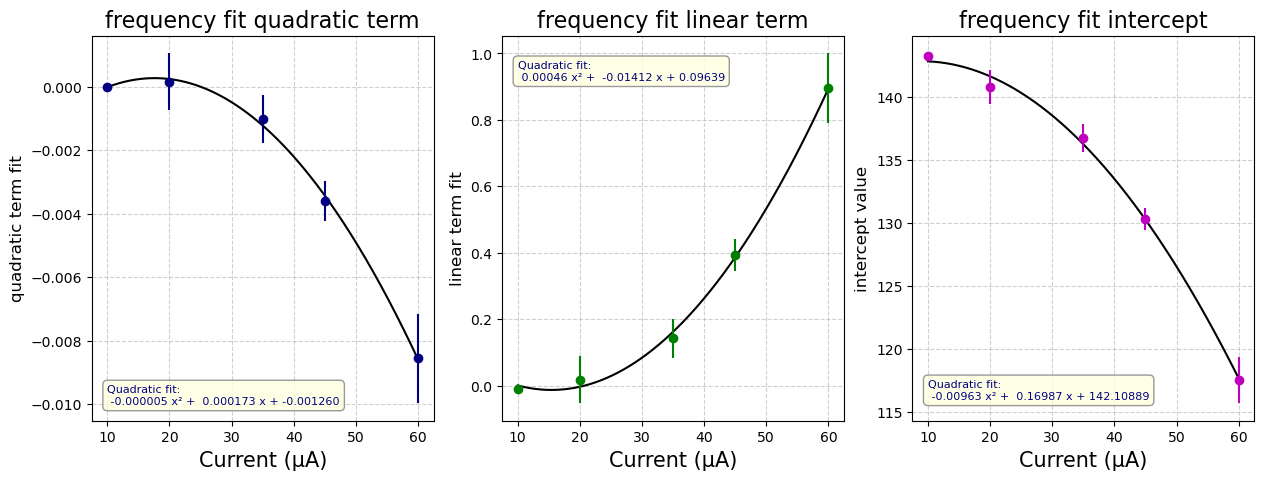

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

a_s = [0,a20,a35,a45,a60]
b_s = [b10,b20,b35,b45,b60]
c_s = [c10,c20,c35,c45,c60]

err_as = [0, err_a20, err_a35, err_a45, err_a60]
err_bs = [err_b10, err_b20, err_b35, err_b45, err_b60]
err_cs = [err_c10, err_c20, err_c35, err_c45, err_c60]

a1_fit, b1_fit, c1_fit = np.polyfit(np.unique(nom_current), a_s, 2, cov=True)[0]
cov1 = np.polyfit(np.unique(nom_current), a_s, 2, cov=True)[1]
a2_fit, b2_fit, c2_fit = np.polyfit(np.unique(nom_current), b_s, 2, cov=True)[0]
cov2 = np.polyfit(np.unique(nom_current), b_s, 2, cov=True)[1]
a3_fit, b3_fit, c3_fit = np.polyfit(np.unique(nom_current), c_s, 2, cov=True)[0]
cov3 = np.polyfit(np.unique(nom_current), c_s, 2, cov=True)[1]

p1 = np.poly1d([a1_fit, b1_fit, c1_fit])
p2 = np.poly1d([a2_fit, b2_fit, c2_fit])
p3 = np.poly1d([a3_fit, b3_fit, c3_fit])

x = np.linspace(np.min(nom_current), np.max(nom_current), 500)


# axes[0].plot(np.unique(nom_current), a1_fit * (np.unique(nom_current))**2 + b1_fit * (np.unique(nom_current)) + c1_fit, color='k', linestyle='--', label='quadratic fit')
axes[0].plot(x, p1(x), color='k', linestyle='-', label='quadratic fit')
axes[0].errorbar(np.unique(nom_current), a_s, err_as, fmt='o', color='navy')
axes[0].grid(True, linestyle='--', alpha=0.6)
# plt.legend(frameon=True, fontsize=9, loc='lower left')
axes[0].set_title("frequency fit quadratic term", fontsize=16)
axes[0].set_xlabel('Current (µA)', fontsize=15)
axes[0].set_ylabel('quadratic term fit', fontsize=12)
axes[0].annotate(
    f"Quadratic fit: \n {a1_fit:.6f} x² +  {b1_fit:.6f} x + {c1_fit:.6f}",
    xy=(10, -0.01),             # point to annotate
    xytext=(10, -0.01),   # text position
    fontsize=8,
    color="navy",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="lightyellow",
        edgecolor="gray",
        alpha=0.8
    )
)

# axes[1].plot(np.unique(nom_current), a2_fit * (np.unique(nom_current))**2 + b2_fit * (np.unique(nom_current)) + c2_fit, color='k', linestyle='--', label='quadratic fit')
axes[1].plot(x, p2(x), color='k', linestyle='-', label='quadratic fit')
axes[1].errorbar(np.unique(nom_current), b_s, err_bs, fmt='o', color='g')
axes[1].grid(True, linestyle='--', alpha=0.6)
# plt.legend(frameon=True, fontsize=9, loc='lower left')
axes[1].set_title("frequency fit linear term", fontsize=16)
axes[1].set_xlabel('Current (µA)', fontsize=15)
axes[1].set_ylabel('linear term fit', fontsize=12)
# axes[1].set_ylim(0, 40)
# axes[0].tight_layout()
# axes[0].show()
axes[1].annotate(
    f"Quadratic fit: \n {a2_fit:.5f} x² +  {b2_fit:.5f} x + {c2_fit:.5f}",
    xy=(10, 0.92),             # point to annotate
    xytext=(10, 0.92),   # text position
    fontsize=8,
    color="navy",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="lightyellow",
        edgecolor="gray",
        alpha=0.8
    )
)

# axes[2].plot(np.unique(nom_current), a3_fit * (np.unique(nom_current))**2 + b3_fit * (np.unique(nom_current)) + c3_fit, color='k', linestyle='--', label='quadratic fit')
axes[2].plot(x, p3(x), color='k', linestyle='-', label='quadratic fit')
axes[2].errorbar(np.unique(nom_current), c_s, err_cs, fmt='o', color='m')
axes[2].grid(True, linestyle='--', alpha=0.6)
# plt.legend(frameon=True, fontsize=9, loc='lower left')
axes[2].set_title("frequency fit intercept", fontsize=16)
axes[2].set_xlabel('Current (µA)', fontsize=15)
axes[2].set_ylabel('intercept value', fontsize=12)
axes[2].annotate(
    f"Quadratic fit: \n {a3_fit:.5f} x² +  {b3_fit:.5f} x + {c3_fit:.5f}",
    xy=(10, 116),             # point to annotate
    xytext=(10, 116),   # text position
    fontsize=8,
    color="navy",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="lightyellow",
        edgecolor="gray",
        alpha=0.8
    )
)

In [7]:
f_all = mean_freq
I_all = nom_current
Y_all = norm_yield

def design_matrix(f, I):
    # columns: [f^2 I^2, f^2 I, f^2, f I^2, f I, f, I^2, I, 1]
    return np.column_stack([
        (f**2)*(I**2), (f**2)*I, f**2,
        f*(I**2),      f*I,      f,
        I**2,          I,        np.ones_like(f)
    ])

# build design
X = design_matrix(f_all, I_all)

# linear least-squares
coef, residuals, rank, s = lstsq(X, Y_all, rcond=None)
# coef is length-9 vector: [A,B,C,D,E,F,G,H,J]

# predicted model
Y_pred = X.dot(coef)

# To get covariance matrix of coef (approx):
N = len(Y_all)
p = X.shape[1]
dof = max(1, N - p)
sigma2 = residuals[0]/dof if residuals.size else np.var(Y_all - Y_pred, ddof=p)
XtX_inv = np.linalg.inv(X.T.dot(X))
cov_coef = sigma2 * XtX_inv

# helper functions
def Y_model_direct(f, I, coef=coef):
    Xrow = design_matrix(np.atleast_1d(f), np.atleast_1d(I))
    return Xrow.dot(coef).item()

def Y_ref_direct(f, coef=coef):
    # set I=0 => terms with I vanish; remaining are C*f^2 + F*f + J
    C = coef[2]; F = coef[5]; J = coef[8]
    return C*f**2 + F*f + J

# correction factor
def correction_factor_direct(f, I, coef=coef):
    Ym = Y_model_direct(f, I, coef)
    Yr = Y_ref_direct(f, coef)
    if Ym == 0:
        return 1.0
    return Yr / Ym

# Example use:
# C = correction_factor_direct(35., 45.)
# Yc = Y_meas * C

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

f = mean_freq
I = nom_current
Y = norm_yield

def design_matrix(f, I):
    return np.column_stack([
        f**2 * I**2, f**2 * I, f**2,
        f * I**2, f * I, f,
        I**2, I, np.ones_like(f)
    ])

X = design_matrix(f, I)
coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

def Y_model(f, I, coef):
    A,B,C,D,E,Fc,G,H,J = coef
    return (A*f**2*I**2 + B*f**2*I + C*f**2 +
            D*f*I**2 + E*f*I + Fc*f +
            G*I**2 + H*I + J)

f_vals = np.linspace(f.min(), f.max(), 60)
I_vals = np.linspace(I.min(), I.max(), 60)
F_grid, I_grid = np.meshgrid(f_vals, I_vals)
Z_grid = Y_model(F_grid, I_grid, coef)

fig = go.Figure()

# Fit surface
fig.add_trace(go.Surface(
    x=F_grid, y=I_grid, z=Z_grid,
    colorscale="Viridis",
    opacity=0.8,
    name="Fit surface"
))

# Plot data points
fig.add_trace(go.Scatter3d(
    x=f, y=I, z=Y,
    mode="markers",
    marker=dict(size=6, color="red"),
    name="Data"
))

fig.update_layout(
    scene=dict(
        xaxis_title="Frequency [Hz]",
        yaxis_title="Current [µA]",
        zaxis_title="EL_CLEAN yield"
    ),
    title="Quadratic 2D Fit Surface",
    width=900, height=700,
    template="plotly_dark"
)

fig.show()


#### We have a fit of the form:

$Y(f,I) = (α_2 I^2 + α_1 I + α_0) f^2 + (β_2 I^2 + β_1 I + β_0)f + (γ_2 I^2 + γ_1 I + γ_0)$

#### Define the "reference" yield as the one given by the frequency dependence at zero current:

$Y_{ref} (f):= Y(f; I=0) = Y(f,0) = α_0 f^2 + β_0 f + γ_0$

#### Then we can define a correction factor (for arbitrary measured yield) as:

$C(f, I) = \frac{Y_{ref}(f)}{Y_{fit}(f, I)}$
$$

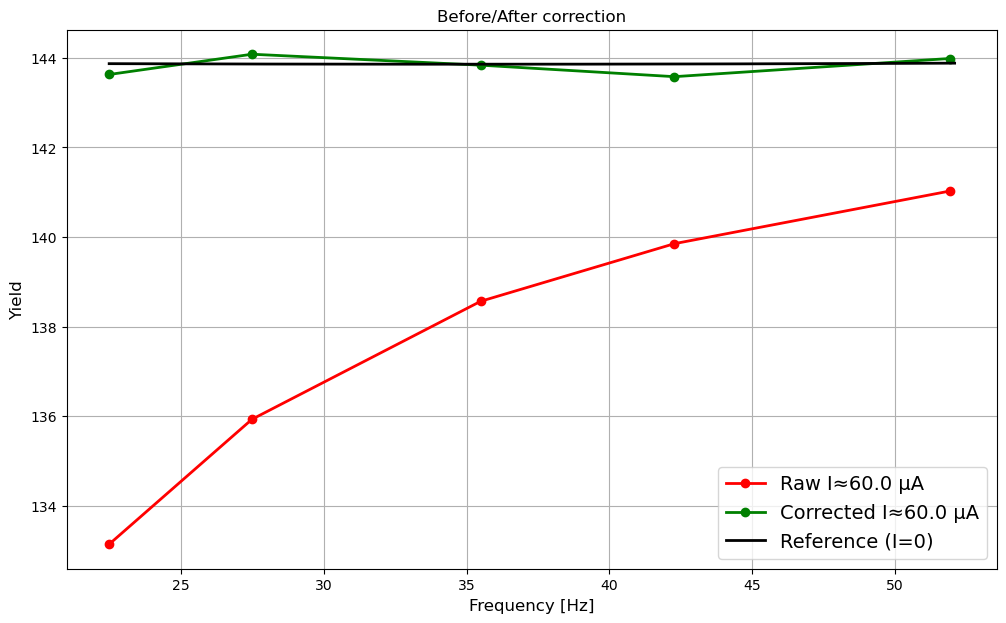

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def design_matrix(f, I):
    return np.column_stack([
        f**2 * I**2, f**2 * I, f**2,
        f * I**2, f * I, f,
        I**2, I, np.ones_like(f)
    ])

X = design_matrix(f, I)
coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

def Y_model(f, I, coef):
    A,B,C,D,E,Fc,G,H,J = coef
    return (A*f**2*I**2 + B*f**2*I + C*f**2 +
            D*f*I**2 + E*f*I + Fc*f +
            G*I**2 + H*I + J)

def Y_ref(f):
    return Y_model(f, np.zeros_like(f), coef)

# Correction factor
C = Y_ref(f) / Y_model(f, I, coef)

# Corrected yield
Y_corr = Y * C

# Plot before and after
plt.figure(figsize=(12,7))
unique_currents = np.unique(np.round(I,1))
for I_fix in unique_currents[4::5]: 
    mask = np.isclose(I, I_fix, atol=0.5)
    if np.any(mask):
        plt.plot(f[mask], Y[mask], "ro-", label=f"Raw I≈{I_fix:.1f} µA", linewidth=2)
        plt.plot(f[mask], Y_corr[mask], "go-", label=f"Corrected I≈{I_fix:.1f} µA", linewidth=2)

f_line = np.linspace(f.min(), f.max(), 200)
plt.plot(f_line, Y_ref(f_line), "k-", linewidth=2, label="Reference (I=0)")

plt.xlabel("Frequency [Hz]", fontsize=12)
plt.ylabel("Yield", fontsize=12)
plt.title("Before/After correction")
plt.legend(fontsize=14)
plt.grid()
plt.show()



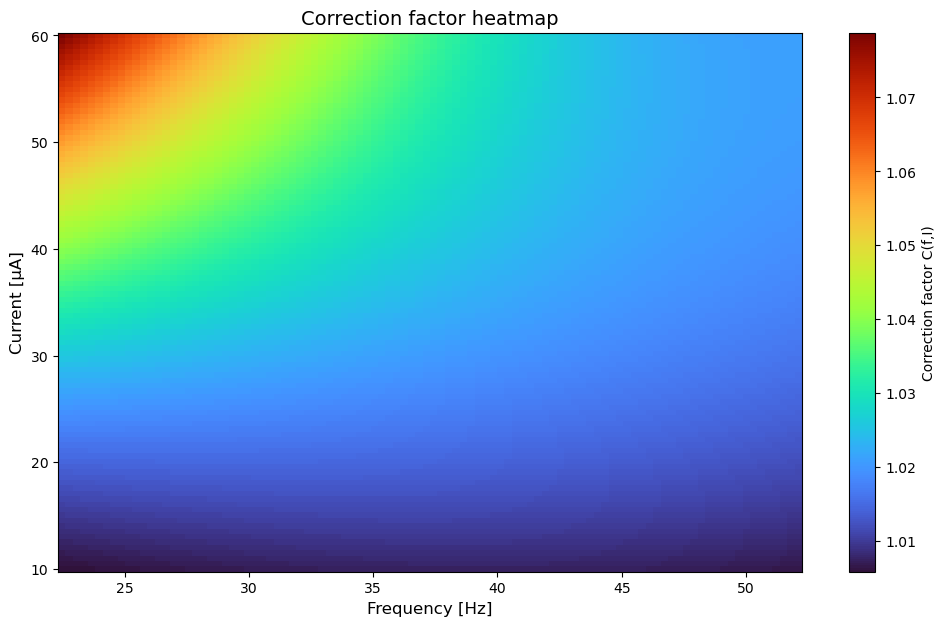

In [10]:
f_grid = np.linspace(f.min(), f.max(), 100)
I_grid = np.linspace(I.min(), I.max(), 100)
F, Igrid = np.meshgrid(f_grid, I_grid)

# Calculate correction factor in the grid
C_grid = Y_ref(F) / Y_model(F, Igrid, coef)

plt.figure(figsize=(12,7))
im = plt.pcolormesh(F, Igrid, C_grid, cmap="turbo", shading="auto")
plt.colorbar(im, label="Correction factor C(f,I)")
plt.xlabel("Frequency [Hz]", fontsize=12)
plt.ylabel("Current [µA]", fontsize=12)
plt.title("Correction factor heatmap", fontsize=14)
plt.show()

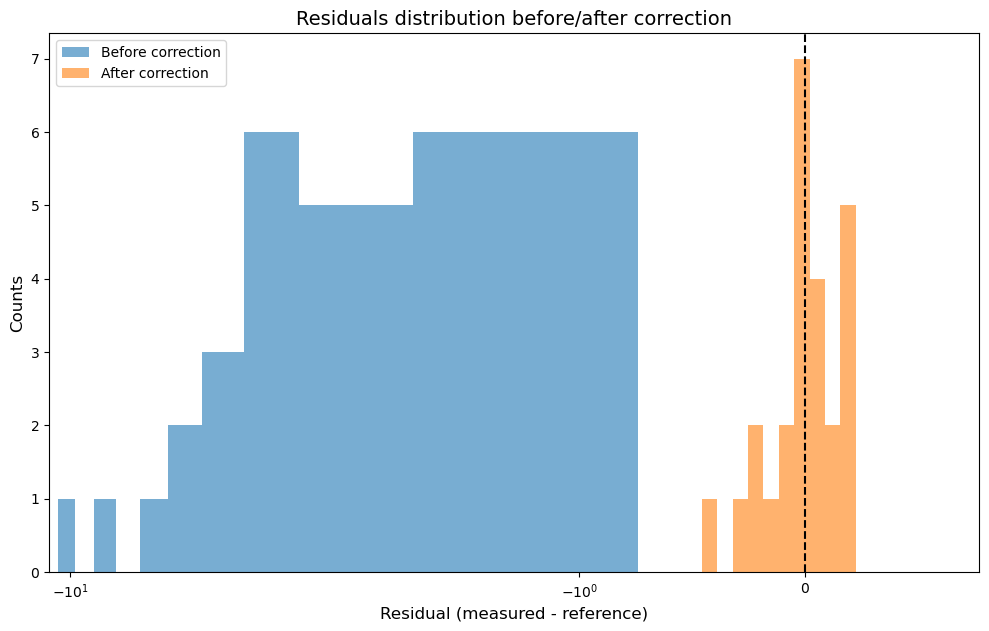

In [11]:
# Residuals analysis
resid_before = Y - Y_ref(f)
resid_after  = Y_corr - Y_ref(f)

plt.figure(figsize=(12,7))
plt.hist(resid_before, bins=10, alpha=0.6, label="Before correction")
plt.hist(resid_after, bins=10, alpha=0.6, label="After correction")
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Residual (measured - reference)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.xscale('symlog')
plt.title("Residuals distribution before/after correction", fontsize=14)
plt.legend()
plt.show()

Extrapolate highest frequency points to zero current (normalize)

In [13]:
coef

array([-4.63644107e-06,  1.30424412e-04,  7.98013139e-05,  4.37559009e-04,
       -1.09899399e-02, -5.56375520e-03, -9.31940585e-03,  1.15703945e-01,
        1.43953881e+02])